# EDA - Predict the Success of Bank telemarketing

-------------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly as ply
import seaborn as sns

In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head()

,last contact date,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,target
0,2009-04-17,26,blue-collar,married,secondary,no,647,yes,no,cellular,357,2,331,1,other,no
1,2009-10-11,52,technician,married,secondary,no,553,yes,no,telephone,160,1,-1,0,NaN,no
2,2010-11-20,44,blue-collar,married,secondary,no,1397,no,no,cellular,326,1,-1,0,NaN,no
3,2009-09-01,33,admin.,married,secondary,no,394,yes,no,telephone,104,3,-1,0,NaN,no
4,2008-01-29,31,entrepreneur,single,tertiary,no,137,no,no,cellular,445,2,-1,0,NaN,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39211 entries, 0 to 39210
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   last contact date  39211 non-null  object
 1   age                39211 non-null  int64 
 2   job                38982 non-null  object
 3   marital            39211 non-null  object
 4   education          37744 non-null  object
 5   default            39211 non-null  object
 6   balance            39211 non-null  int64 
 7   housing            39211 non-null  object
 8   loan               39211 non-null  object
 9   contact            28875 non-null  object
 10  duration           39211 non-null  int64 
 11  campaign           39211 non-null  int64 
 12  pdays              39211 non-null  int64 
 13  previous           39211 non-null  int64 
 14  poutcome           9760 non-null   object
 15  target             39211 non-null  object
dtypes: int64(6), object(10)
memory usage: 4.

In [6]:
df.describe()

,age,balance,duration,campaign,pdays,previous
count,39211.000000,39211.000000,39211.000000,39211.000000,39211.000000,39211.000000
mean,42.120247,5441.781719,439.062789,5.108770,72.256051,11.826171
std,12.709352,16365.292065,769.096291,9.890153,160.942593,44.140259
min,18.000000,-8019.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,98.000000,109.000000,1.000000,-1.000000,0.000000
50%,40.000000,549.000000,197.000000,2.000000,-1.000000,0.000000
75%,50.000000,2030.000000,380.000000,4.000000,-1.000000,0.000000
max,95.000000,102127.000000,4918.000000,63.000000,871.000000,275.000000


## Data Cleaning

In [7]:
missing_values = df.isnull().sum()

In [8]:
missing_values

last contact date        0
age                      0
job                    229
marital                  0
education             1467
default                  0
balance                  0
housing                  0
loan                     0
contact              10336
duration                 0
campaign                 0
pdays                    0
previous                 0
poutcome             29451
target                   0
dtype: int64

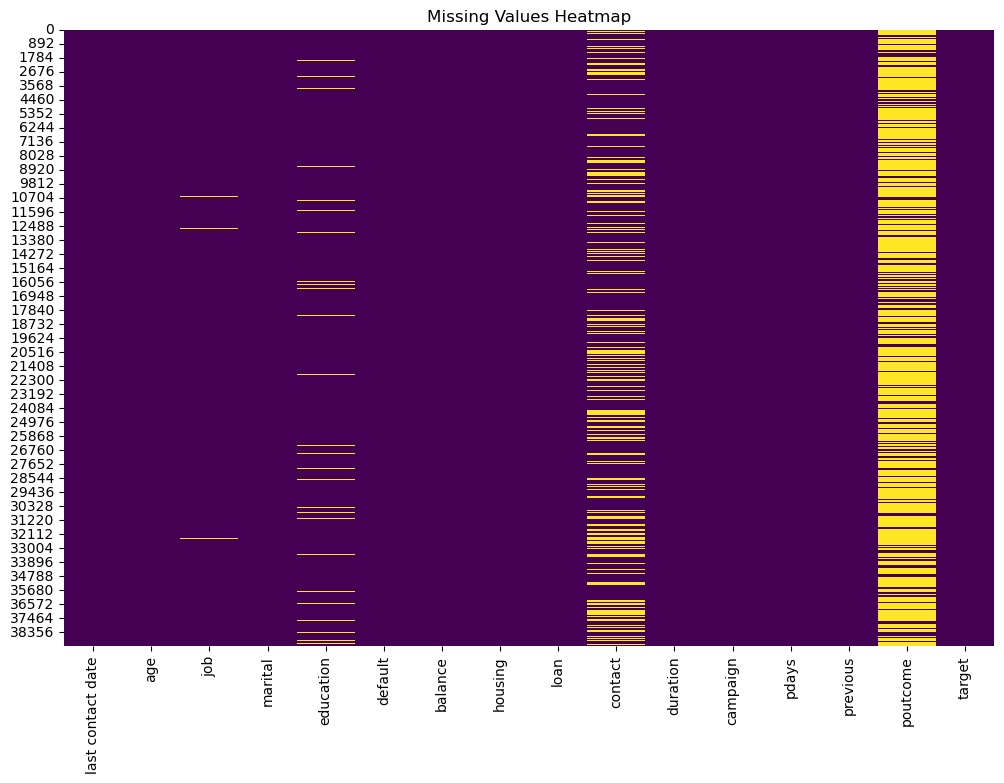

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [10]:
df['contact'] = df['contact'].replace('', 'unknown')
df['poutcome'] = df['poutcome'].replace('', 'unknown')

## Univariate Analysis

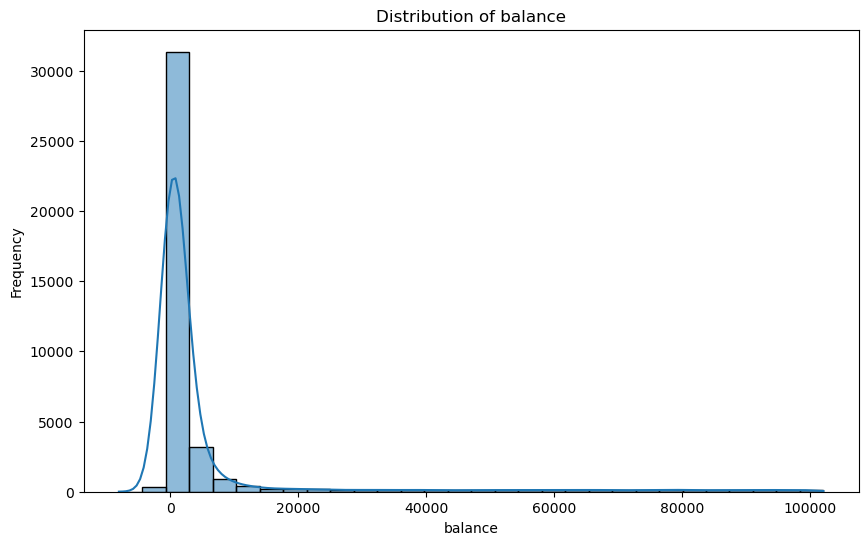

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['balance'], kde=True, bins=30)
plt.title(f"Distribution of balance")
plt.xlabel('balance')
plt.ylabel("Frequency")
plt.show()

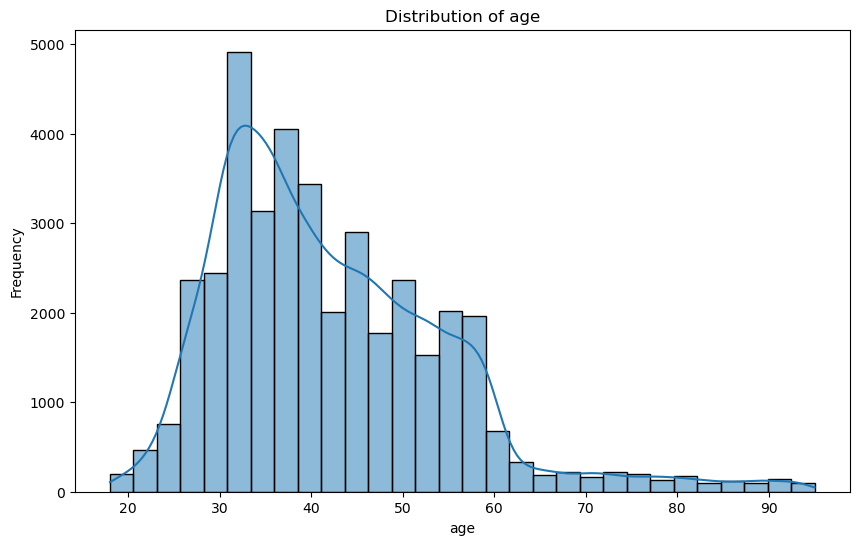

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, bins=30)
plt.title(f"Distribution of age")
plt.xlabel('age')
plt.ylabel("Frequency")
plt.show()

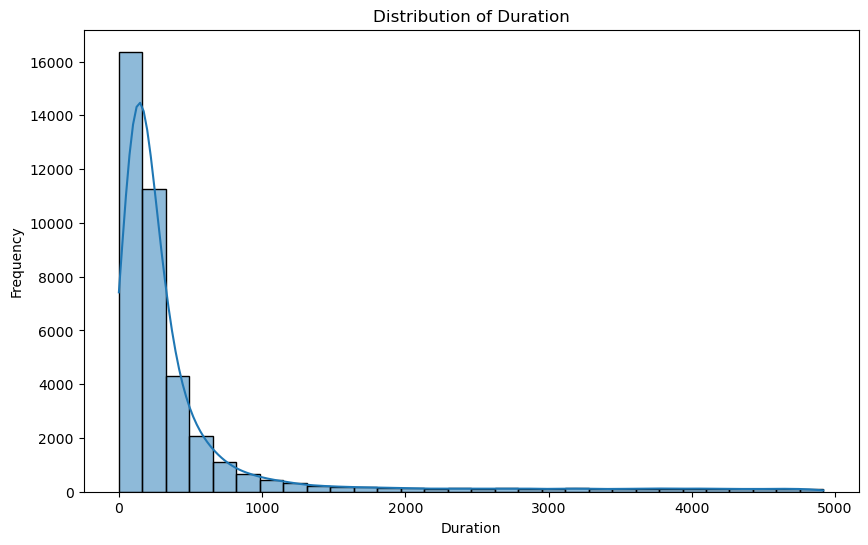

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['duration'], kde=True, bins=30)
plt.title(f"Distribution of Duration")
plt.xlabel('Duration')
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_411349/535319386.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='job', data=df, palette="muted")


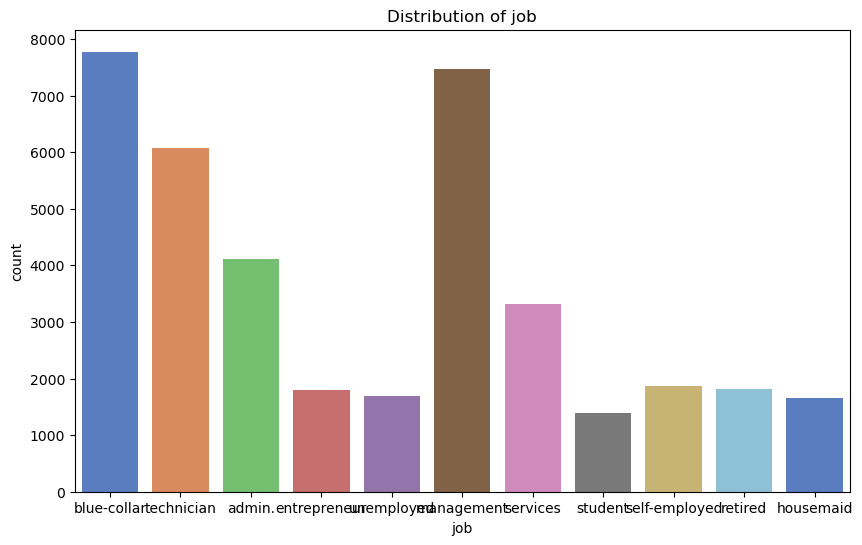

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(x='job', data=df, palette="muted")
plt.title(f"Distribution of job")
plt.show()

/tmp/ipykernel_411349/378584662.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='education', data=df, palette="muted")


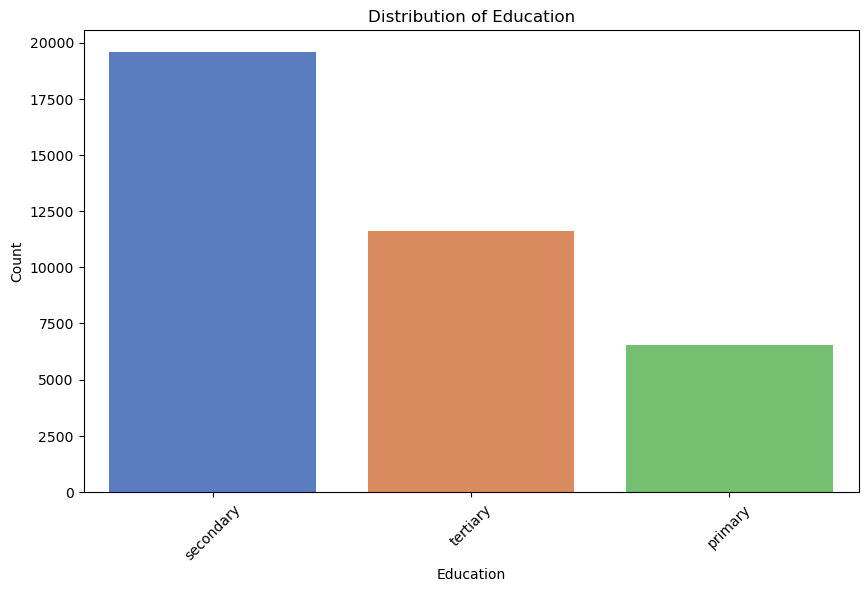

In [15]:
plt.figure(figsize=(10, 6))
sns.countplot(x='education', data=df, palette="muted")
plt.title(f"Distribution of Education")
plt.xlabel('Education')
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_411349/1876173481.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette="muted")


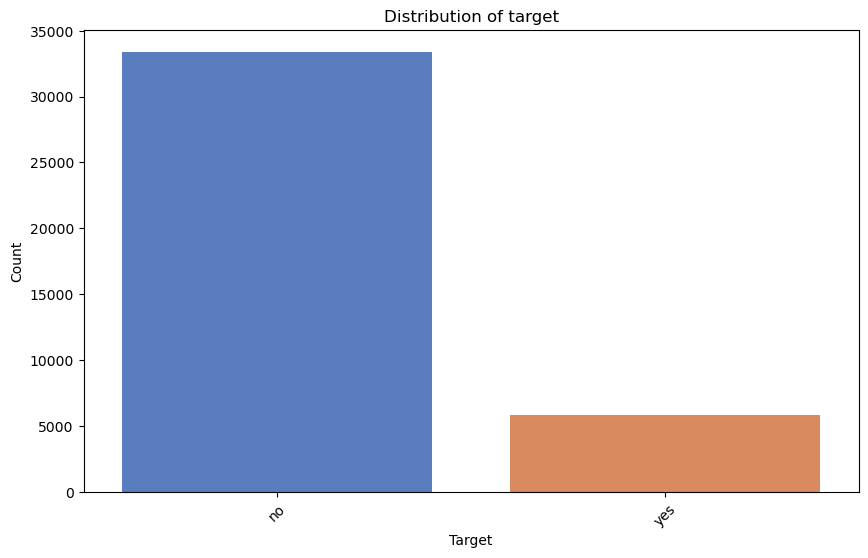

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(x='target', data=df, palette="muted")
plt.title(f"Distribution of target")
plt.xlabel('Target')
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Bivariate Analysis

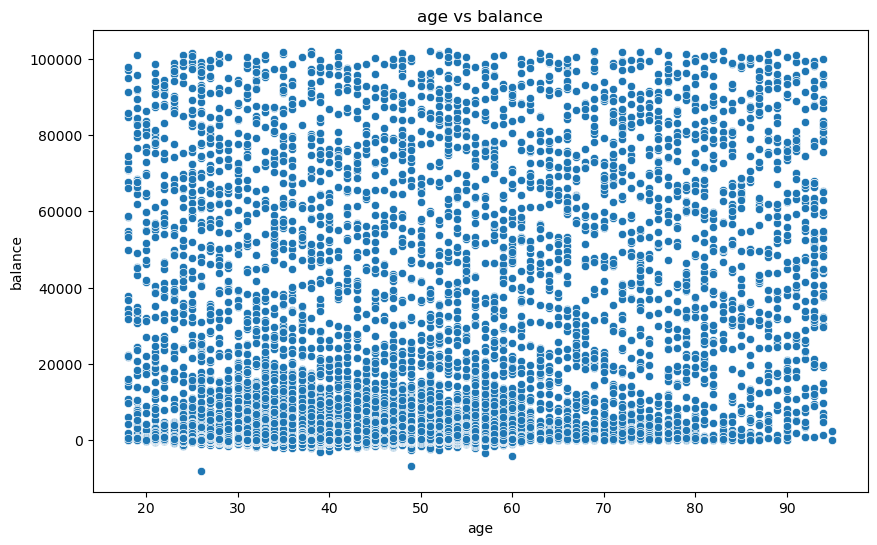

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='balance', data=df)
plt.title(f"age vs balance")
plt.xlabel('age')
plt.ylabel('balance')
plt.show()

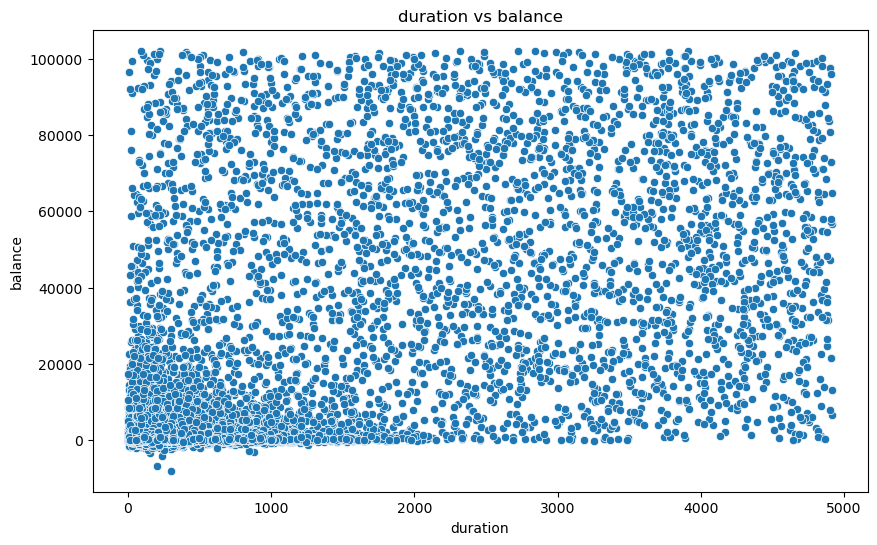

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration', y='balance',data=df)
plt.title(f"duration vs balance")
plt.xlabel('duration')
plt.ylabel('balance')
plt.show()

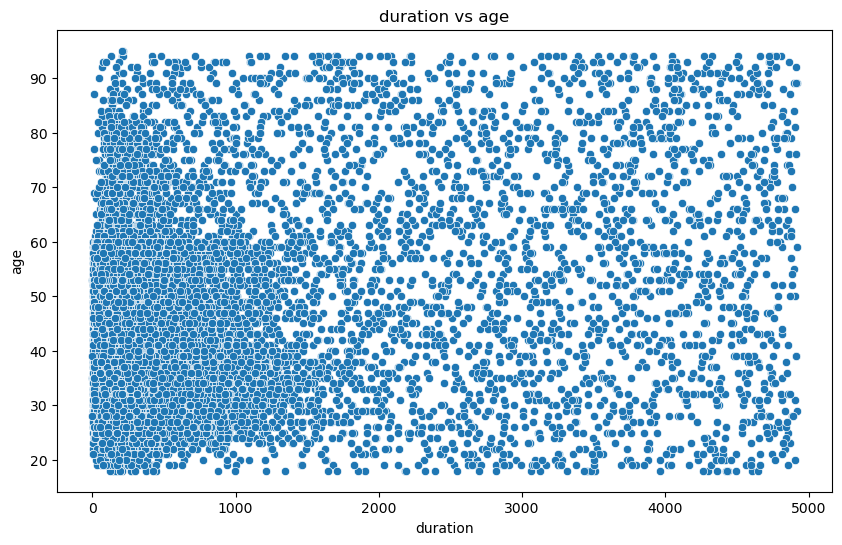

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration', y='age', data=df)
plt.title(f"duration vs age")
plt.xlabel('duration')
plt.ylabel('age')
plt.show()

/tmp/ipykernel_411349/3912549813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='job', y='balance', data=df,palette='Set3')


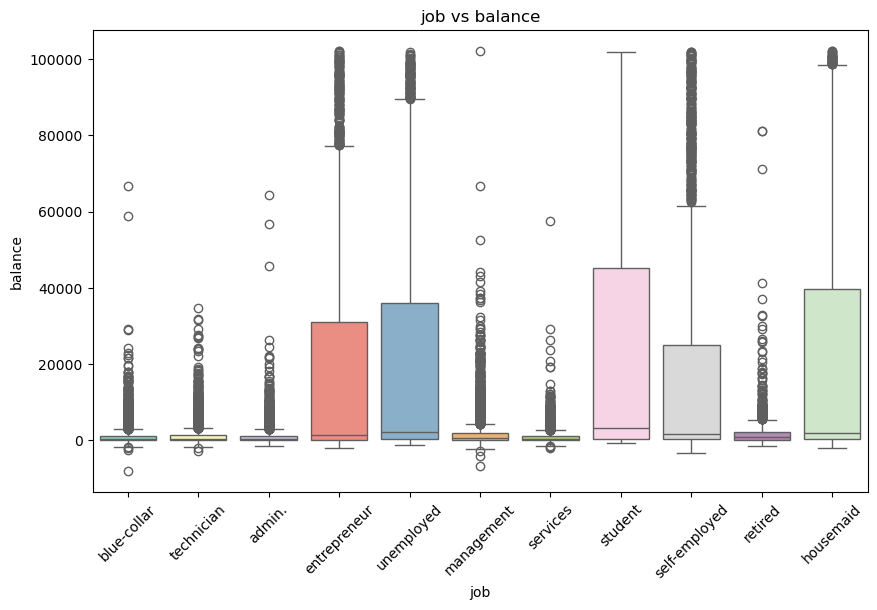

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='job', y='balance', data=df,palette='Set3')
plt.title(f"job vs balance")
plt.xlabel('job')
plt.ylabel('balance')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_411349/1605080480.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='job', y='age', data=df,palette='Set3')


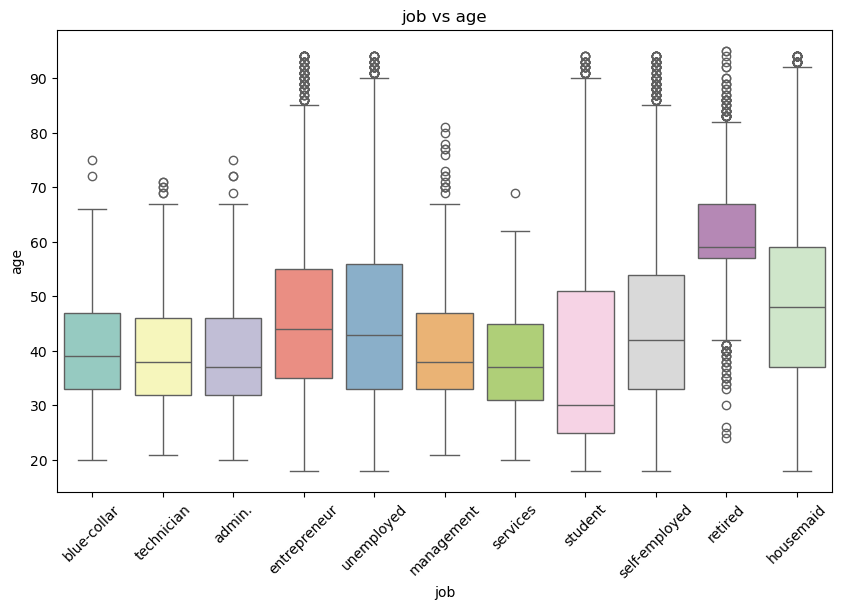

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='job', y='age', data=df,palette='Set3')
plt.title(f"job vs age")
plt.xlabel('job')
plt.ylabel('age')
plt.xticks(rotation=45)
plt.show()

## Multivariate Analysis

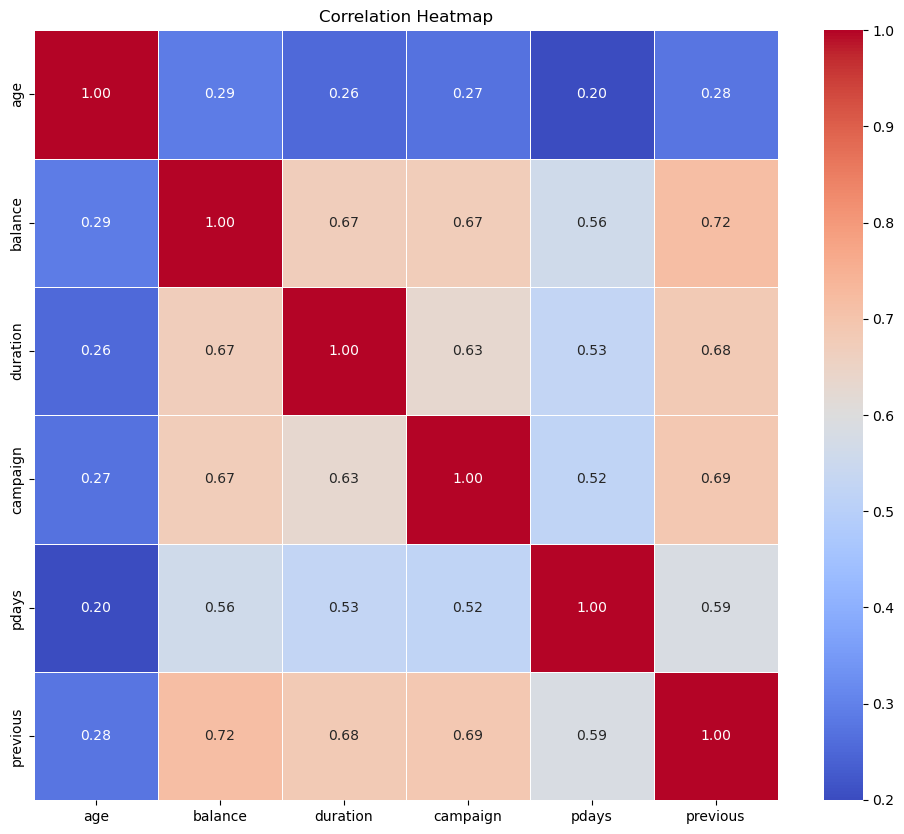

In [22]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

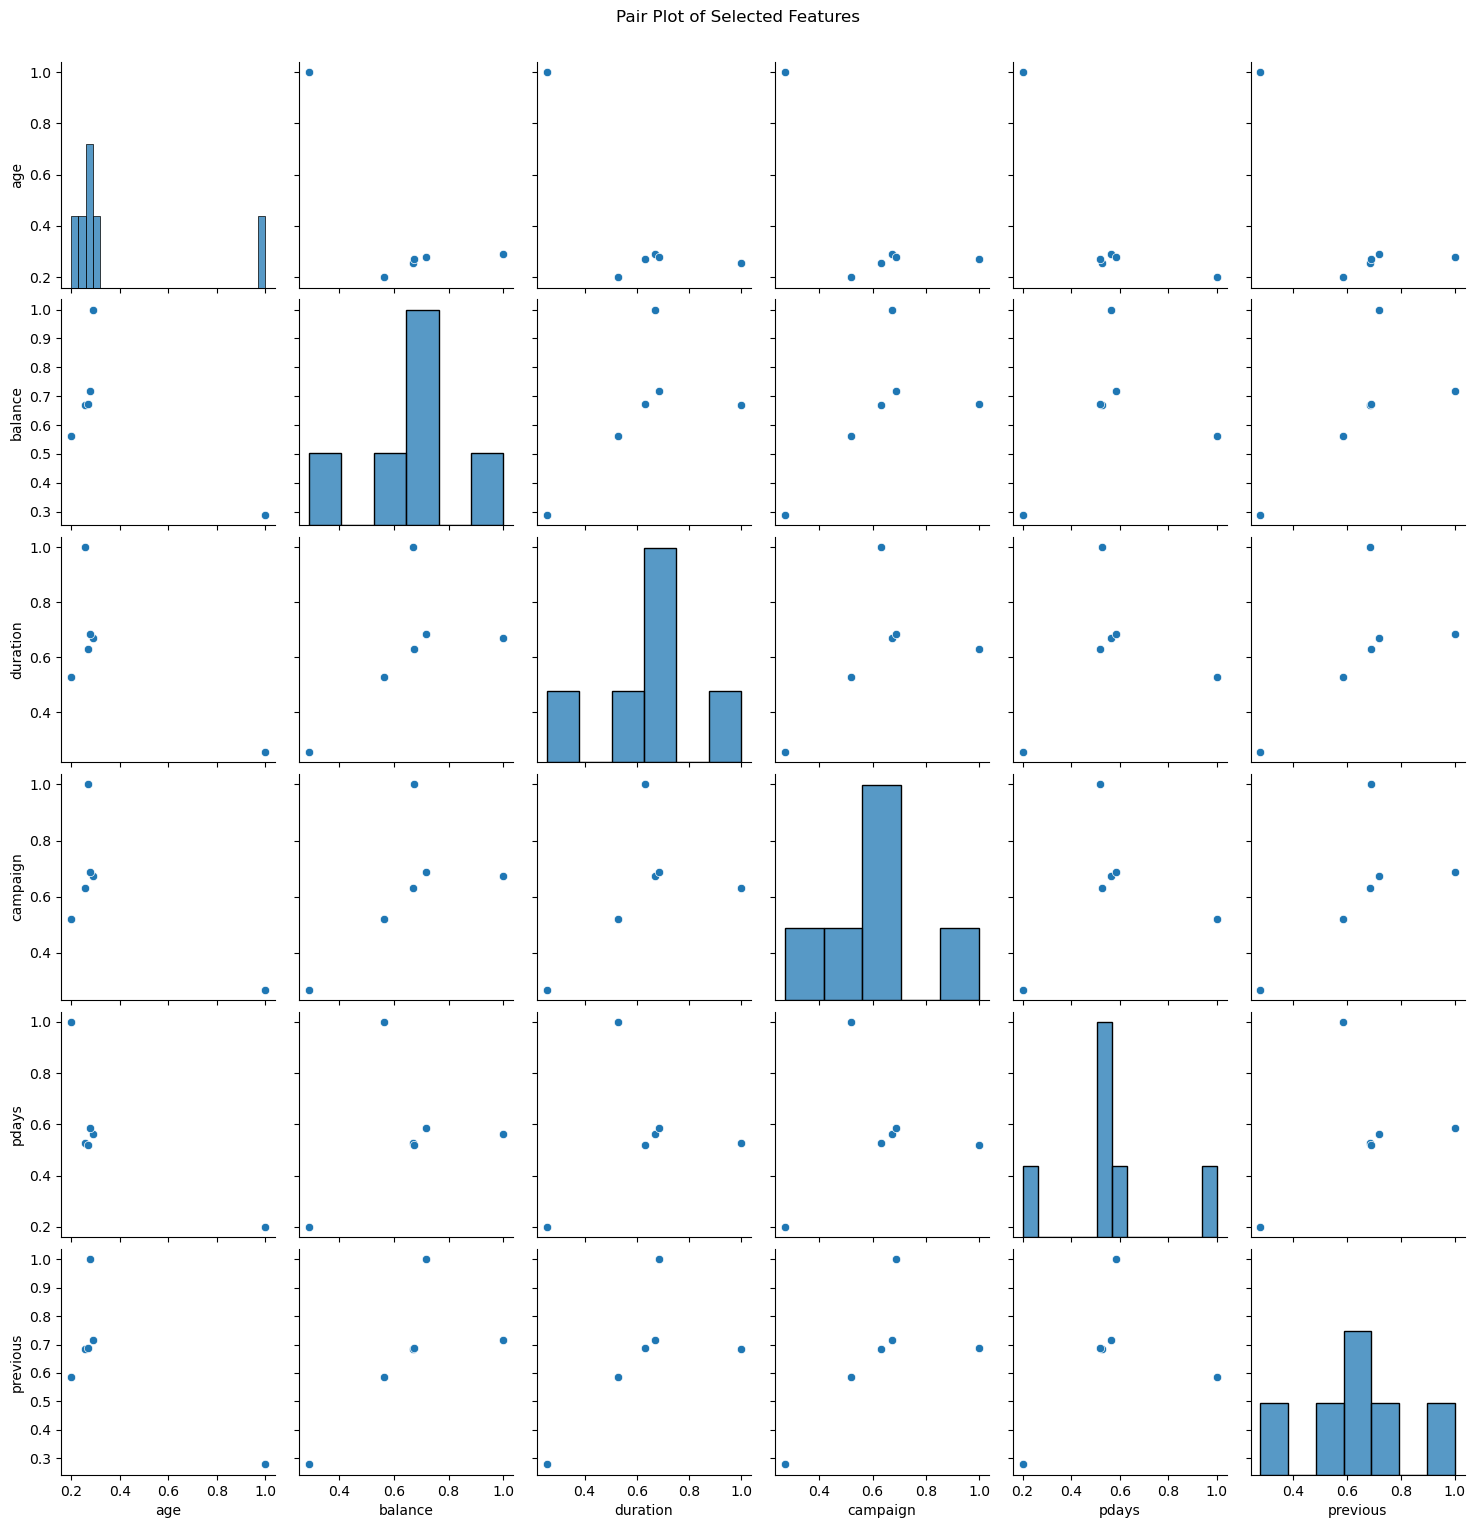

In [23]:
sns.pairplot(corr_matrix, height=2.5)
plt.suptitle("Pair Plot of Selected Features", y=1.02)
plt.show()

## Data Transformation

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

In [25]:
numeric_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
categorical_features = ['job', 'marital', 'education', 'housing', 'loan', 'poutcome']

In [26]:
# Data Normalization
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

In [27]:
# One Hot Encoding
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [28]:
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_features)])


In [29]:
model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(random_state=42))])

In [30]:
df['target'] = df['target'].apply(lambda x: 1 if x == 'yes' else 0)

X = df.drop('target', axis=1)
y = df['target']

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'housing',
                                                   'loan', 'poutcome'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [33]:
y_pred = model.predict(X_test)

In [34]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92      6645
           1       0.57      0.23      0.33      1198

    accuracy                           0.86      7843
   macro avg       0.72      0.60      0.62      7843
weighted avg       0.83      0.86      0.83      7843

Accuracy: 0.86


In [35]:
output = pd.DataFrame({'id': X_test.index, 'target': ['yes' if pred == 1 else 'no' for pred in y_pred]})
output.to_csv('submission.csv', index=False)

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the train and test datasets
train_data = pd.read_csv('train.csv')  # Update the path to your train file if needed
test_data = pd.read_csv('test.csv')    # Update the path to your test file if needed

# Drop the 'last contact date' column if present, as it may not provide much predictive power
if 'last contact date' in train_data.columns:
    train_data = train_data.drop('last contact date', axis=1)
if 'last contact date' in test_data.columns:
    test_data = test_data.drop('last contact date', axis=1)

# Encoding the target variable in the training data
train_data['target'] = train_data['target'].apply(lambda x: 1 if x == 'yes' else 0)

# Splitting features and target for training data
X_train = train_data.drop('target', axis=1)
y_train = train_data['target']

# Using the features from the test data
X_test = test_data

# Preprocessing
numeric_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
categorical_features = ['job', 'marital', 'education', 'housing', 'loan', 'poutcome']

# Preprocessing pipelines for numerical and categorical features
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine the numeric and categorical transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

# Basic model pipeline
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', LogisticRegression(random_state=42))])

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Create the output DataFrame in the desired format
output = pd.DataFrame({'id': X_test.index, 'target': ['yes' if pred == 1 else 'no' for pred in y_pred]})

# Ensure output has more than 10,000 rows, adding extra rows if necessary
if output.shape[0] < 10000:
    extra_rows = 10000 - output.shape[0]
    extra_data = pd.DataFrame({'id': range(output.shape[0], output.shape[0] + extra_rows), 'target': 'no'})
    output = pd.concat([output, extra_data], ignore_index=True)

# Save to 'submission.csv'
output.to_csv('submission.csv', index=False)

print("Model accuracy: {:.2f}".format(model.score(X_train, y_train)))

Model accuracy: 0.86


## Data Reduction using PCA

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load train and test datasets
train_data = pd.read_csv('train.csv') 
test_data = pd.read_csv('test.csv')    

# Drop unnecessary columns if they exist
if 'last contact date' in train_data.columns:
    train_data = train_data.drop('last contact date', axis=1)
if 'last contact date' in test_data.columns:
    test_data = test_data.drop('last contact date', axis=1)

# Encode target variable in the training data
train_data['target'] = train_data['target'].apply(lambda x: 1 if x == 'yes' else 0)

# Split features and target for training
X_train = train_data.drop('target', axis=1)
y_train = train_data['target']
X_test = test_data

# Define numeric and categorical features
numeric_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
categorical_features = ['job', 'marital', 'education', 'housing', 'loan', 'poutcome']

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Apply preprocessing pipeline on X_train and X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Feature Selection with RFE (using Logistic Regression as the base estimator)
rfe_selector = RFE(LogisticRegression(random_state=42, max_iter=500), n_features_to_select=10, step=1)
rfe_selector = rfe_selector.fit(X_train_processed, y_train)
X_train_rfe = rfe_selector.transform(X_train_processed)
X_test_rfe = rfe_selector.transform(X_test_processed)

# Dimensionality Reduction with PCA
pca = PCA(n_components=10)  # Adjust n_components as needed
X_train_pca = pca.fit_transform(X_train_rfe)
X_test_pca = pca.transform(X_test_rfe)

# Initialize models
log_reg = LogisticRegression(random_state=42, max_iter=500)
naive_bayes = GaussianNB()
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(probability=True, random_state=42)

# Dictionary to store model accuracies
model_accuracies = {}

# Train and evaluate each model using PCA-transformed data
models = {
    'Logistic Regression': log_reg,
    'Naive Bayes': naive_bayes,
    'K-Nearest Neighbors': knn,
    'Support Vector Machine': svm
}

for model_name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred_train = model.predict(X_train_pca)
    model_accuracies[model_name] = accuracy_score(y_train, y_pred_train)
    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_train, y_pred_train))

# Ensemble with Voting Classifier
voting_clf = VotingClassifier(estimators=[
    ('log_reg', log_reg),
    ('naive_bayes', naive_bayes),
    ('svm', svm)
], voting='soft')

voting_clf.fit(X_train_pca, y_train)
y_pred_voting = voting_clf.predict(X_test_pca)
voting_accuracy = accuracy_score(y_train, voting_clf.predict(X_train_pca))
model_accuracies['Voting Classifier'] = voting_accuracy
print("\nVoting Classifier Classification Report:")
print(classification_report(y_train, voting_clf.predict(X_train_pca)))

# Create output for submission
output = pd.DataFrame({'id': X_test.index, 'target': ['yes' if pred == 1 else 'no' for pred in y_pred_voting]})

# Ensure output has at least 10,000 rows
if output.shape[0] < 10000:
    extra_rows = 10000 - output.shape[0]
    extra_data = pd.DataFrame({'id': range(output.shape[0], output.shape[0] + extra_rows), 'target': 'no'})
    output = pd.concat([output, extra_data], ignore_index=True)

output.to_csv('submission.csv', index=False)

print("Model Accuracies:", model_accuracies)


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     33384
           1       0.56      0.23      0.32      5827

    accuracy                           0.86     39211
   macro avg       0.72      0.60      0.62     39211
weighted avg       0.83      0.86      0.83     39211


Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90     33384
           1       0.42      0.46      0.44      5827

    accuracy                           0.82     39211
   macro avg       0.66      0.67      0.67     39211
weighted avg       0.83      0.82      0.83     39211


K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     33384
           1       0.70      0.52      0.60      5827

    accuracy                           0.90     39211
   m